In [53]:
%load_ext autoreload  
%autoreload 2  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


In [54]:
# Import the Data class from the ocpy library to handle observational data.
from ocpy.data import Data

# Read the dataset from the "ny_vir.xlsx" Excel file.
# The file is expected to contain columns for Time (BJD), O-C values, and Errors.
data = Data.from_file("ny_vir.xlsx")

# Calculate weights for the observations based on their errors (1/sigma^2).
data = data.calculate_weights()

(<Axes: ylabel='O−C'>, <Axes: xlabel='Cycle', ylabel='Resid'>)

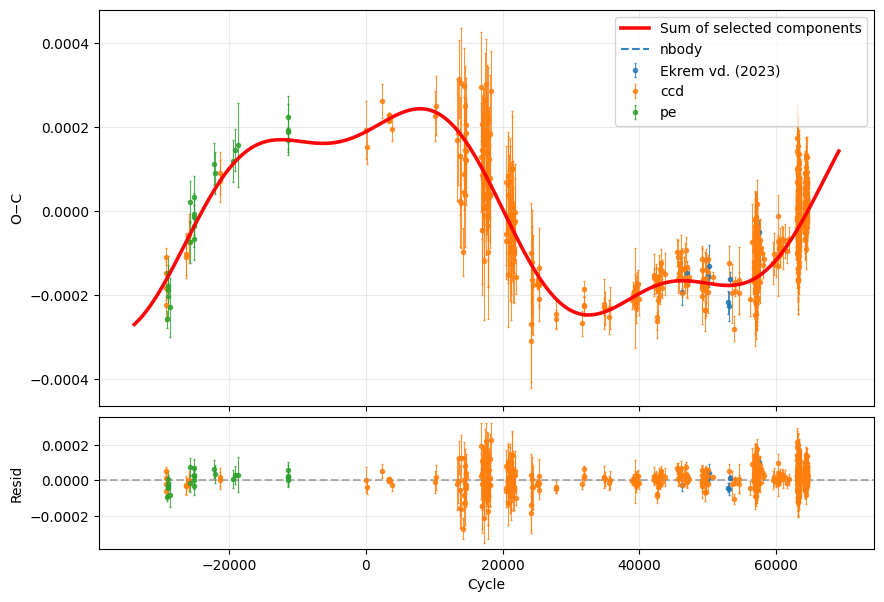

In [55]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter
import numpy as np
# Referans Zaman ve Periyot (Görselden güncellendi)
T0_ref = 2453174.442769
P_ref = 0.1010159690
nbody = NewtonianModel(
    central_mass = Parameter(value=0.471 + 0.14, fixed=True), # Mps + Mns ≈ 0.611
    T0_ref = T0_ref,
    P_ref = P_ref,
    bodies = [
        # 1. Cisim (Value 1: P=3195, M=2.283 Mjup)
        {
            "m": Parameter(value=2.283 * 0.000954588, fixed=False, std=1, min=0), # 2.283 Mjup -> Msun
            "P": Parameter(value=3195.0, fixed=False, std=1000, min=0), 
            "e": Parameter(value=0.0, fixed=True, std=1), # e=0 (Görselde belirtilmiş)
            "omega": Parameter(value=0.0, fixed=True, std=200), # w=0 (Görselde belirtilmiş)
            "T": Parameter(value=2453619.0, fixed=False, std=10000), # T_peri (BJD)
        },
        # 2. Cisim (Value 2: P=8404, M=3.996 Mjup)
        {
            "m": Parameter(value=3.996 * 0.000954588, fixed=False, std=1, min=0), # 3.996 Mjup -> Msun
            "P": Parameter(value=8404.0, fixed=False, std=1000, min=0), 
            "e": Parameter(value=0.0, fixed=True, std=1), # e=0
            "omega": Parameter(value=0.0, fixed=True, std=200), # w=0
            "T": Parameter(value=2451010.0, fixed=False, std=10000), # T_peri (BJD)
        }
    ],
    name="nbody"
)
# Not: 'data.calculate_oc' fonksiyonu ocpy.data modülünde bulunmadığı için
# burada hata alabilirsiniz. Ancak istediğiniz formatı (kendi Data objeniz tanımlıysa) koruyorum.
oc = data.calculate_oc(T0_ref, P_ref, model_type="pymc")
oc.plot(model=[nbody])

In [56]:
res = oc.fit(
    [nbody], 
    tune=500,          
    draws=500, 
    chains=8,           
    progressbar=True,
)

Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>Slice: [nbody_b1_m]
>Slice: [nbody_b1_P]
>Slice: [nbody_b1_T]
>Slice: [nbody_b2_m]
>Slice: [nbody_b2_P]
>Slice: [nbody_b2_T]


Output()

Sampling 8 chains for 500 tune and 500 draw iterations (4_000 + 4_000 draws total) took 3306 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


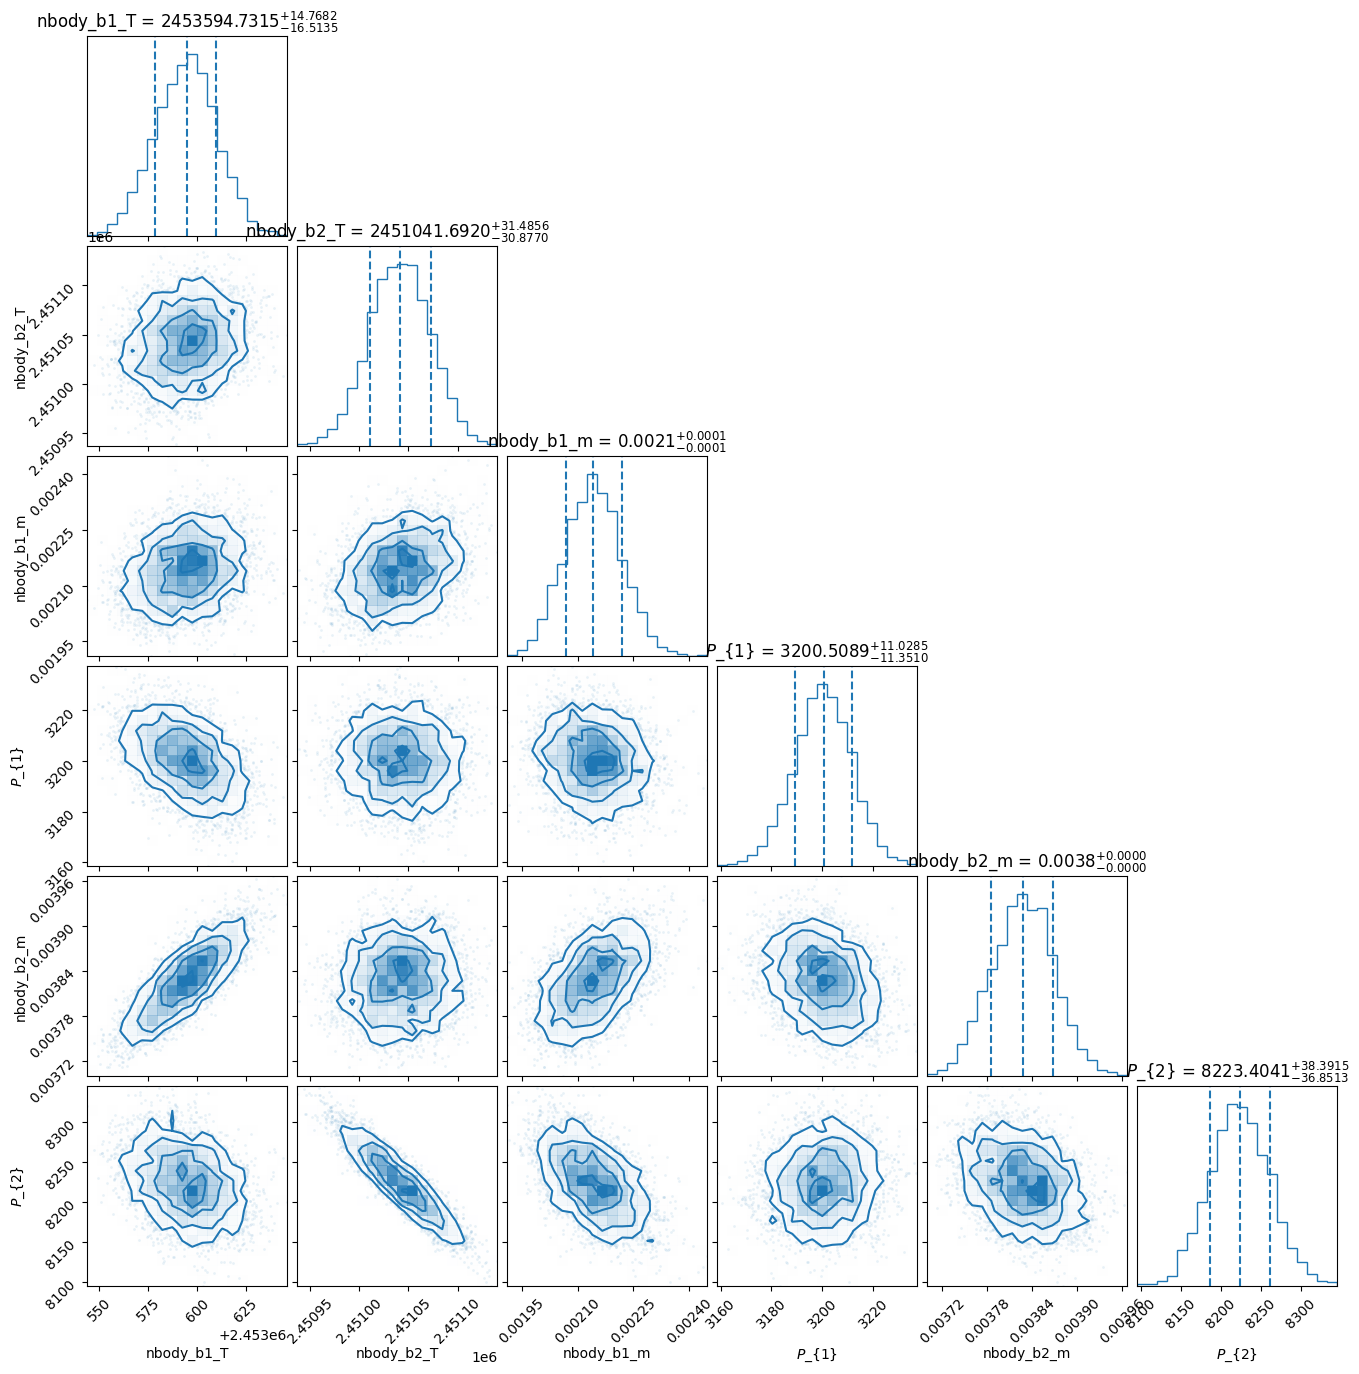

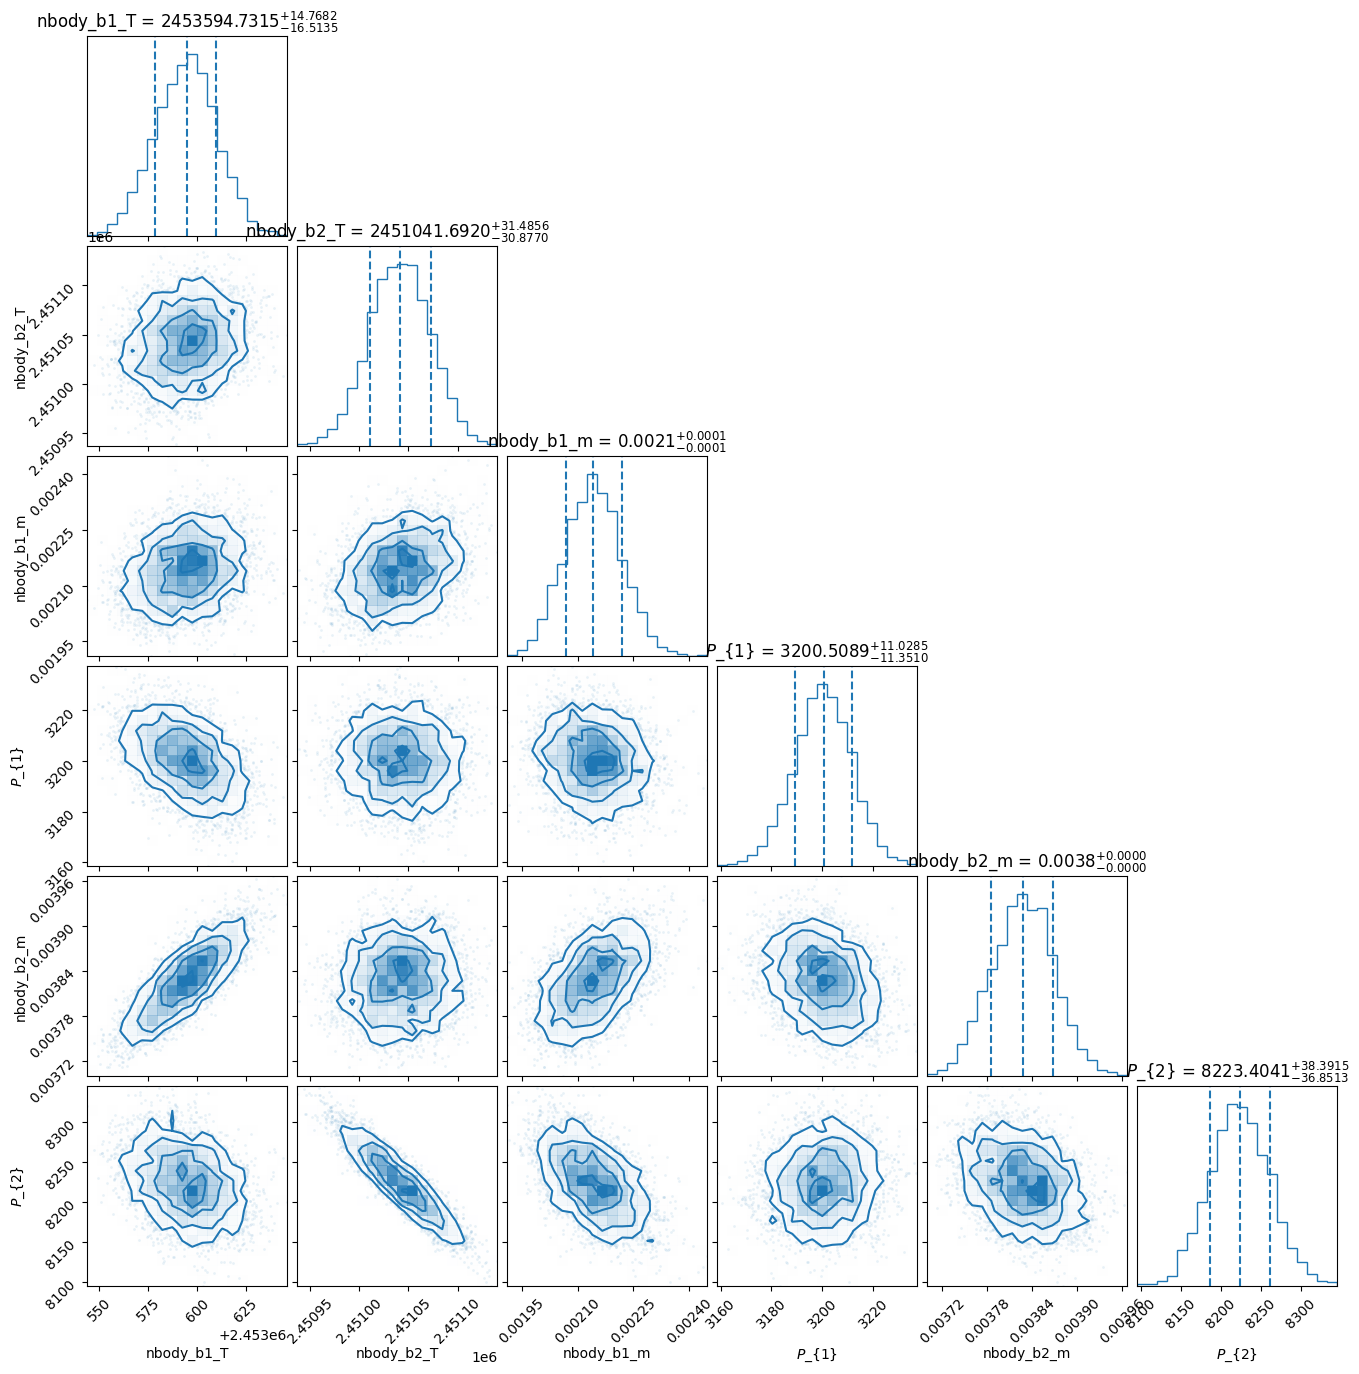

In [57]:
oc.corner(
    res, 
    color="tab:blue",                        # Grafik rengi
    show_titles=True                         # Tepede en iyi değerleri yazdır
)

(<Axes: ylabel='O−C'>, <Axes: xlabel='Cycle', ylabel='Resid'>)

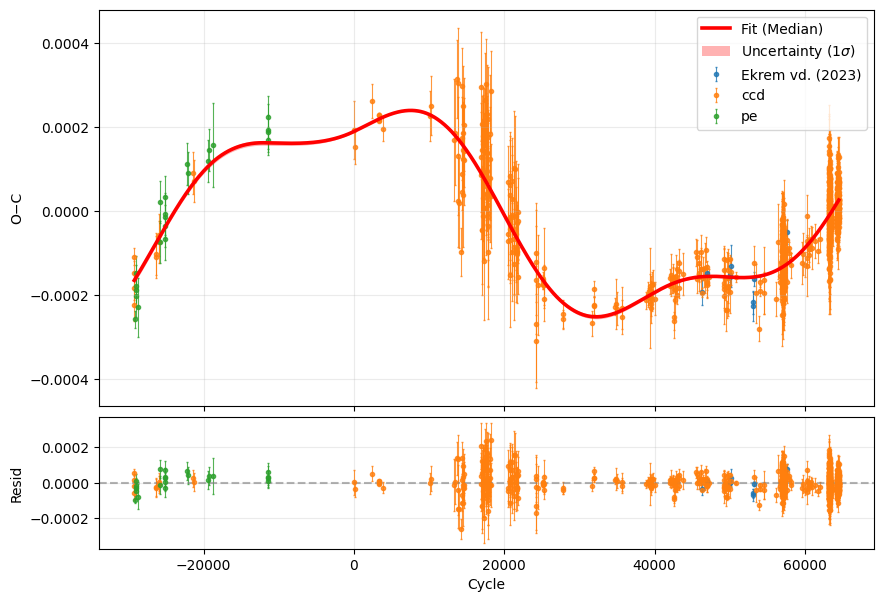

In [61]:
oc.plot(model=res)